In [101]:
import pandas as pd
import os

This dataset includes phishing emails and safe emails.

In [102]:
df_new = pd.read_csv("Phishing_validation_emails.csv")
df_new

,Email Text,Email Type
0,"Dear Jordan, your subscription has been succes...",Safe Email
1,"Dear Casey, thank you for your purchase. Your ...",Safe Email
2,Congratulations! You've won a $3000 gift card....,Phishing Email
3,You have a new secure message from your bank. ...,Phishing Email
4,Your package delivery is pending. Please provi...,Phishing Email
...,...,...
1995,Your payment has been declined. Update your bi...,Phishing Email
1996,"Hi Taylor, it was great meeting you at the con...",Safe Email
1997,Your subscription is about to expire. Renew no...,Phishing Email
1998,"Hi John, just a reminder about the project dea...",Safe Email


In [103]:
for index, row in df_new.iterrows():
    if row["Email Type"] == "Safe Email":
        df_new.at[index, "Label"] = 0
    else:
        df_new.at[index, "Label"] = 1

In [104]:
df_new

,Email Text,Email Type,Label
0,"Dear Jordan, your subscription has been succes...",Safe Email,0.0
1,"Dear Casey, thank you for your purchase. Your ...",Safe Email,0.0
2,Congratulations! You've won a $3000 gift card....,Phishing Email,1.0
3,You have a new secure message from your bank. ...,Phishing Email,1.0
4,Your package delivery is pending. Please provi...,Phishing Email,1.0
...,...,...,...
1995,Your payment has been declined. Update your bi...,Phishing Email,1.0
1996,"Hi Taylor, it was great meeting you at the con...",Safe Email,0.0
1997,Your subscription is about to expire. Renew no...,Phishing Email,1.0
1998,"Hi John, just a reminder about the project dea...",Safe Email,0.0


In [105]:
def load_emails_clean(folder, label):
    emails = []
    
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        
        try:
            with open(path, 'r', encoding='latin-1') as f:
                content = f.read()
                
                # removes headers 
                parts = content.split('\n\n', 1)
                body = parts[1] if len(parts) > 1 else parts[0]
                
                emails.append([body, label])
        
        except:
            continue
    
    return pd.DataFrame(emails, columns=['text', 'label'])

In [106]:
ham_df = load_emails_clean("easy_ham", 0)
spam_df = load_emails_clean("spam", 1)

df_old = pd.concat([ham_df, spam_df]).reset_index(drop=True)

df_old.head()

,text,label
0,"URL: http://www.newsisfree.com/click/-1,838114...",0
1,\nhttp://www.guardian.co.uk/Print/0%2c3858%2c4...,0
2,> > You're probably running exmh on a local ma...,0
3,"On Sun, 1 Sep 2002, Reza B'Far (eBuilt) wrote:...",0
4,"URL: http://www.newsisfree.com/click/-5,829698...",0


In [107]:
import re
import html
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def clean_text(text):
    text = str(text).lower()
    
    
    text = html.unescape(text)
    
    # URLs/HTML 
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    
    # only letters
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # filter words 
    custom_stop_words = {'nbsp', 'src', 'href', 'width', 'height', 'align', 'font', 'br', 'td', 'tr'}
    
    words = text.split()
    words = [w for w in words if w not in ENGLISH_STOP_WORDS 
             and w not in custom_stop_words 
             and len(w) > 2]
    
    return ' '.join(words)
    
df_old['Text'] = df_old['text'].apply(clean_text)
df_new['Text'] = df_new['Email Text'].apply(clean_text)
df_new['Text'] = df_new['Text'].apply(clean_text)

In [108]:
df_old = df_old[df_old['Text'].str.len() > 10]
df_new = df_new[df_new['Text'].str.len() > 10]

df_old = df_old[df_old['Text'].str.strip() != ""]
df_new = df_new[df_new['Text'].str.strip() != ""]

This dataset includes spam and ham from 2005.

In [109]:
df_old

,text,label,Text
0,"URL: http://www.newsisfree.com/click/-1,838114...",0,url date arts fourth art raid philanthropist h...
1,\nhttp://www.guardian.co.uk/Print/0%2c3858%2c4...,0,making mesh new way fast mobile net access spe...
2,> > You're probably running exmh on a local ma...,0,probably running exmh local machine running re...
3,"On Sun, 1 Sep 2002, Reza B'Far (eBuilt) wrote:...",0,sun sep reza far ebuilt wrote forces developer...
4,"URL: http://www.newsisfree.com/click/-5,829698...",0,url date dekalb daily chronicle
...,...,...,...
3047,HABERDAR.COM - HABER VE MEDYA PORTALI\nArtýk t...,1,haberdar com haber medya portali art haberleri...
3048,\n<HTML><HEAD><TITLE></TITLE></HEAD><BODY BGCO...,1,tax problems owe irs money debt help licensed ...
3049,"<!DOCTYPE HTML PUBLIC ""-//W3C//DTD HTML 4.0 Tr...",1,beautiful custom websites complete body text v...
3050,There is NO stumbling on to it! \n\nThe greate...,1,stumbling greatest way marketing century undou...


In [110]:
df_old['label'].value_counts()


label
0    2549
1     499
Name: count, dtype: int64

In [111]:
print(df_new.columns)

Index(['Email Text', 'Email Type', 'Label', 'Text'], dtype='str')


This is the combined dataset with spam/phishing and ham/safe emails from 2025 and 2005. 0 means safe, 1 means spam/phishing.

standardize the data

In [112]:

df_old = df_old.rename(columns={'label': 'Label'})

# df_old
df_old['Year'] = 2005
df_old['Label'] = df_old['Label'].astype(int)
df_old = df_old[['Text', 'Label', 'Year']]

# df_new
if 'Email Text' in df_new.columns:
    df_new['Text'] = df_new['Email Text'].apply(clean_text)

df_new['Label'] = df_new['Label'].astype(int)
df_new['Year'] = 2025
df_new = df_new[['Text', 'Label', 'Year']]

# combine 
df = pd.concat([df_old, df_new]).reset_index(drop=True)

df.head()

,Text,Label,Year
0,url date arts fourth art raid philanthropist h...,0,2005
1,making mesh new way fast mobile net access spe...,0,2005
2,probably running exmh local machine running re...,0,2005
3,sun sep reza far ebuilt wrote forces developer...,0,2005
4,url date dekalb daily chronicle,0,2005


In [113]:
def predict_email(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    return "Phishing" if pred == 1 else "Safe"

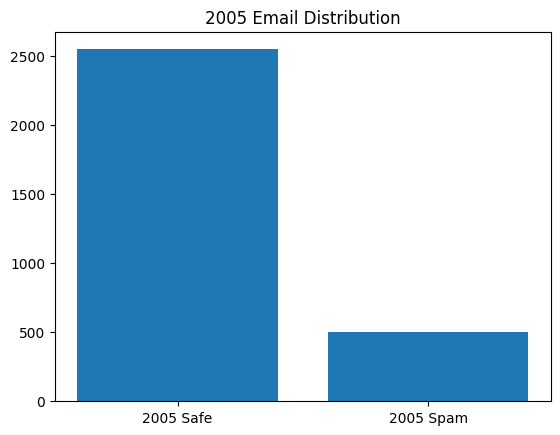

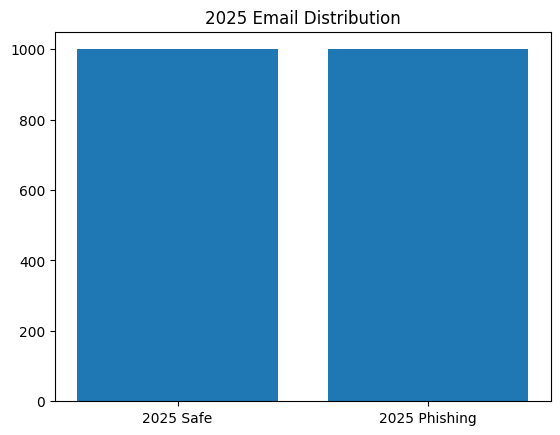

In [114]:
import matplotlib.pyplot as plt

old_counts = df_old['Label'].value_counts()
new_counts = df_new['Label'].value_counts()

plt.bar(['2005 Safe', '2005 Spam'], [old_counts[0], old_counts[1]])
plt.title("2005 Email Distribution")
plt.show()

plt.bar(['2025 Safe', '2025 Phishing'], [new_counts[0], new_counts[1]])
plt.title("2025 Email Distribution")
plt.show()

In [115]:
from collections import Counter

def get_top_words(text_series, n=10):
    words = ' '.join(text_series).split()
    return Counter(words).most_common(n)

In [116]:
df_old['Clean_Text'] = df_old['Text']  
df_new['Clean_Text'] = df_new['Text'].apply(clean_text)

spam_2005 = df_old[df_old['Label'] == 1]
spam_2025 = df_new[df_new['Label'] == 1]

top_2005 = dict(get_top_words(spam_2005['Clean_Text']))
top_2025 = dict(get_top_words(spam_2025['Clean_Text']))

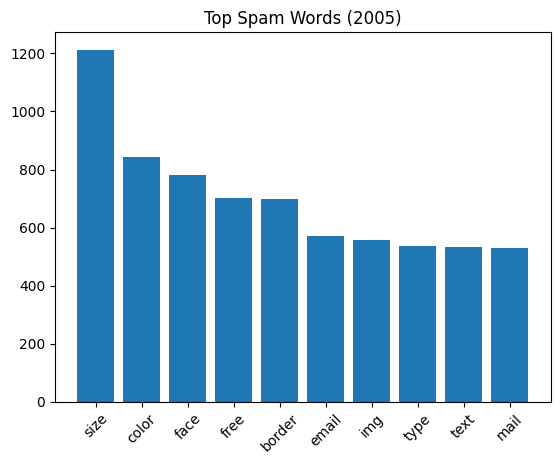

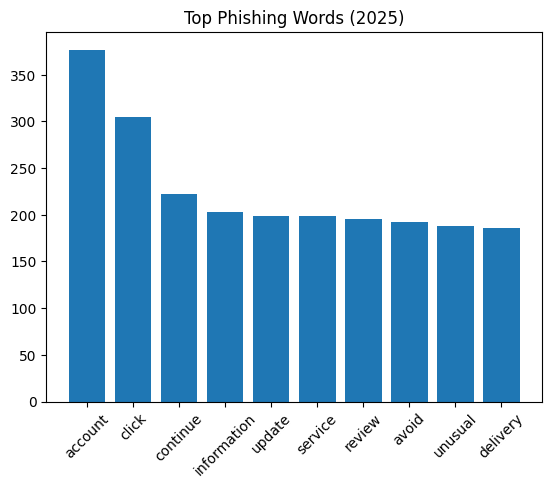

In [117]:
plt.bar(top_2005.keys(), top_2005.values())
plt.xticks(rotation=45)
plt.title("Top Spam Words (2005)")
plt.show()

plt.bar(top_2025.keys(), top_2025.values())
plt.xticks(rotation=45)
plt.title("Top Phishing Words (2025)")
plt.show()
